# Практическая работа: алгоритм k ближайших соседей (KNN)

Цели работы:

- познакомиться с алгоритмом k ближайших соседей для классификации;
- научиться применять KNN к разным наборам данных;
- понять влияние числа соседей k и масштабирования признаков;
- сравнить KNN с логистической регрессией на простом примере;
- освоить базовые метрики качества (accuracy, confusion matrix).

In [14]:
# 0. Импорт библиотек

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(0)

## 0. Синтетические датасеты для кредитов и растений

Создадим два набора данных:

- `credit` — прогноз дефолта по кредиту;
- `plants` — прогноз болезни растений.

Это делает практику воспроизводимой, без внешних файлов.

In [15]:
def make_credit_data(n_samples=800, random_state=42):
    rng = np.random.default_rng(random_state)

    # Возраст: 21–70
    age = rng.normal(loc=40, scale=10, size=n_samples).clip(21, 70)

    # Доход (тыс. руб.): 20–300
    income = rng.lognormal(mean=np.log(60), sigma=0.5, size=n_samples)
    income = income.clip(20, 300)

    # Стаж работы (лет)
    years_employed = rng.uniform(0, 30, size=n_samples)
    years_employed = np.minimum(years_employed, age - 18)
    years_employed = np.clip(years_employed, 0, None)

    # Количество просрочек
    past_due = rng.poisson(lam=1.0, size=n_samples).clip(0, 10)

    # Сумма кредита (тыс. руб.)
    credit_amount = income * rng.uniform(2, 6, size=n_samples) + rng.normal(0, 20, size=n_samples)
    credit_amount = credit_amount.clip(50, 1500)

    # Наличие залога
    collateral = rng.binomial(1, p=0.4, size=n_samples)

    # Логистическая модель вероятности дефолта (для правдоподобия)
    beta0 = -3.0
    beta_age = -0.01
    beta_income = -0.005
    beta_years = -0.03
    beta_past_due = 0.6
    beta_amount = 0.001
    beta_collateral = -0.8

    z = (
        beta0
        + beta_age * age
        + beta_income * (income / 10)
        + beta_years * years_employed
        + beta_past_due * past_due
        + beta_amount * (credit_amount / 100)
        + beta_collateral * collateral
    )

    p_default = 1 / (1 + np.exp(-z))
    default = rng.binomial(1, p_default)

    data = pd.DataFrame({
        "age": age,
        "income": income,
        "years_employed": years_employed,
        "past_due": past_due,
        "credit_amount": credit_amount,
        "collateral": collateral,
        "default": default,
        "p_default_true": p_default,
    })

    return data


def make_plants_data(n_samples=800, random_state=123):
    rng = np.random.default_rng(random_state)

    # Температура (°C)
    temp = rng.normal(loc=22, scale=5, size=n_samples).clip(10, 35)

    # Влажность (%)
    humidity = rng.beta(a=2, b=2, size=n_samples) * 70 + 30  # 30–100

    # Осадки (мм)
    rain = rng.exponential(scale=50, size=n_samples).clip(0, 300)

    # Плотность посадки
    density = rng.uniform(2, 10, size=n_samples)

    # Сорт (устойчивость): 0, 1, 2
    variety = rng.integers(0, 3, size=n_samples)

    # Логистическая модель вероятности болезни
    beta0 = -8.0
    beta_temp = 0.15
    beta_temp2 = -0.003
    beta_humidity = 0.05
    beta_rain = 0.01
    beta_density = 0.25
    beta_variety = -0.8

    z = (
        beta0
        + beta_temp * temp
        + beta_temp2 * temp**2
        + beta_humidity * (humidity / 10)
        + beta_rain * (rain / 50)
        + beta_density * density
        + beta_variety * variety
    )

    p_disease = 1 / (1 + np.exp(-z))
    disease = rng.binomial(1, p_disease)

    data = pd.DataFrame({
        "temp": temp,
        "humidity": humidity,
        "rain": rain,
        "density": density,
        "variety": variety,
        "disease": disease,
        "p_disease_true": p_disease,
    })

    return data


credit = make_credit_data(n_samples=800, random_state=42)
plants = make_plants_data(n_samples=800, random_state=123)

credit.head(), plants.head()

(         age      income  years_employed  past_due  credit_amount  collateral  \
 0  43.047171   39.323484       22.637194         1     182.301344           0   
 1  29.600159   34.900290        2.933640         0      64.497993           0   
 2  47.504512   71.282226       14.046942         1     203.071388           1   
 3  49.405647   72.528862        6.016874         1     250.915316           0   
 4  21.000000  114.206718        3.000000         1     652.147208           1   
 
    default  p_default_true  
 0        0        0.028542  
 1        0        0.032270  
 2        0        0.015827  
 3        0        0.042765  
 4        0        0.027907  ,
         temp   humidity       rain   density  variety  disease  p_disease_true
 0  17.054393  63.842487  30.478123  9.956495        2        0        0.006060
 1  20.161067  34.658306  38.513617  6.064382        1        0        0.004976
 2  28.439626  79.656072  51.197912  2.735617        2        0        0.001269
 3  2

## 1. KNN на датасете Iris и сравнение с логистической регрессией

Начнём с Iris: сначала рассмотрим бинарную классификацию (setosa vs не‑setosa),
потом многоклассовый случай и сравнение границ решений KNN и логистической регрессии на 2D.

In [16]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names
target_names_iris = iris.target_names

print("Размер X:", X_iris.shape)
print("Размер y:", y_iris.shape)
print("Признаки:", feature_names_iris)
print("Классы:", target_names_iris)

df_iris = pd.DataFrame(X_iris, columns=feature_names_iris)
df_iris["target"] = y_iris
df_iris.head()

Размер X: (150, 4)
Размер y: (150,)
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Классы: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


**Задание 1.1.**  
1. Посмотрите таблицу `df_iris`.  
2. Какие признаки, по вашему мнению, лучше всего разделяют виды цветков?

### 1.1 Бинарная классификация: setosa vs не‑setosa с KNN и логистической регрессией

Возьмём два признака: длина и ширина лепестка. Будем решать задачу бинарной классификации.

In [17]:
# Бинарный таргет: setosa (1) vs остальные (0)
y_binary = (y_iris == 0).astype(int)

# Два признака для визуализации границы
X_two = df_iris[["petal length (cm)", "petal width (cm)"]].values

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_two, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

X_train_b_scaled[:5]

array([[ 0.27470219,  0.16778873],
       [ 0.10094478, -0.10325461],
       [ 0.56429788,  0.3033104 ],
       [-1.23119538, -0.78086296],
       [ 0.39054047,  0.3033104 ]])

In [18]:
# KNN с k=5
knn_bin = KNeighborsClassifier(n_neighbors=5)
knn_bin.fit(X_train_b_scaled, y_train_b)
y_pred_knn_b = knn_bin.predict(X_test_b_scaled)

print("KNN (k=5)")
print("Accuracy:", accuracy_score(y_test_b, y_pred_knn_b))
print("Confusion matrix:\n", confusion_matrix(y_test_b, y_pred_knn_b))

# Логистическая регрессия для сравнения
log_reg_bin = LogisticRegression(solver="liblinear")
log_reg_bin.fit(X_train_b_scaled, y_train_b)
y_pred_log_b = log_reg_bin.predict(X_test_b_scaled)

print("\nЛогистическая регрессия")
print("Accuracy:", accuracy_score(y_test_b, y_pred_log_b))
print("Confusion matrix:\n", confusion_matrix(y_test_b, y_pred_log_b))

KNN (k=5)
Accuracy: 1.0
Confusion matrix:
 [[30  0]
 [ 0 15]]

Логистическая регрессия
Accuracy: 1.0
Confusion matrix:
 [[30  0]
 [ 0 15]]


**Задание 1.2.**  
1. Сравните accuracy и матрицы ошибок KNN и логистической регрессии.  
2. Какой метод лучше отделяет setosa от остальных на этой паре признаков?

#### Визуализация границ решений KNN и логистической регрессии

Построим границы решений в пространстве двух признаков: длина и ширина лепестка.

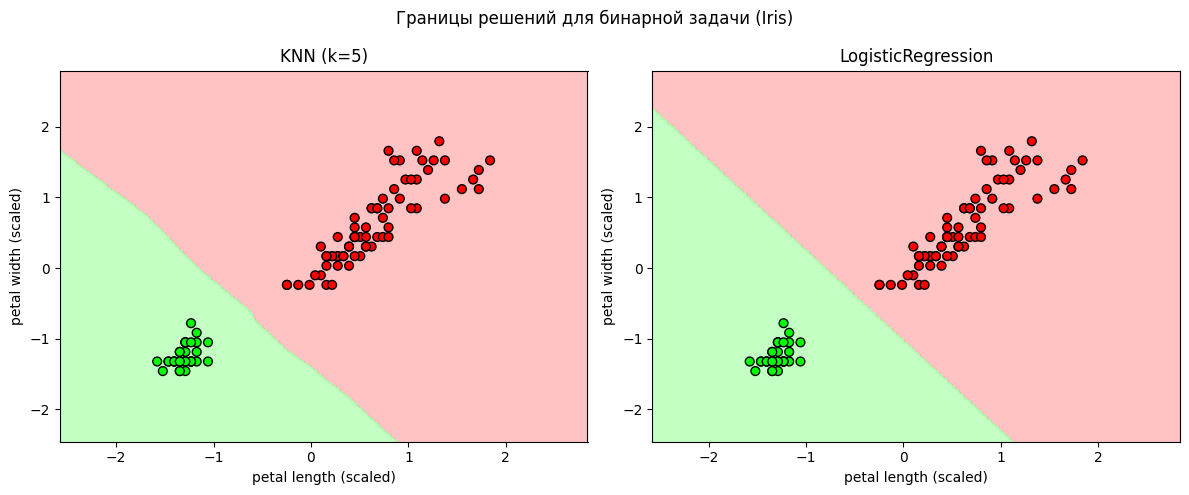

In [19]:
def plot_decision_boundaries(models, X_train, y_train, title):
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    cmap_light = ListedColormap(["#FFAAAA", "#AAFFAA"])
    cmap_bold = ListedColormap(["#FF0000", "#00FF00"])

    plt.figure(figsize=(12, 5))

    for i, (name, model) in enumerate(models.items(), 1):
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        plt.subplot(1, len(models), i)
        plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.7)
        plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_bold, edgecolor="k", s=40)
        plt.xlabel("petal length (scaled)")
        plt.ylabel("petal width (scaled)")
        plt.title(name)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

models_bin = {
    "KNN (k=5)": knn_bin,
    "LogisticRegression": log_reg_bin
}

plot_decision_boundaries(models_bin, X_train_b_scaled, y_train_b, "Границы решений для бинарной задачи (Iris)")

**Задание 1.3.**  
1. Чем визуально отличается граница решения KNN от границы логистической регрессии?  
2. Как это связано с тем, что логистическая регрессия строит линейную границу, а KNN — более сложную, адаптивную границу? [2][web:35][web:40]

### 1.2 Многоклассовая классификация: три вида ирисов с KNN

Теперь будем предсказывать сразу три вида: setosa, versicolor, virginica.

In [20]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

knn_multi = KNeighborsClassifier(n_neighbors=5)
knn_multi.fit(X_train_m_scaled, y_train_m)

y_pred_m = knn_multi.predict(X_test_m_scaled)

print("KNN, 3 класса")
print("Accuracy:", accuracy_score(y_test_m, y_pred_m))
print("Confusion matrix:\n", confusion_matrix(y_test_m, y_pred_m))
print("Classification report:\n", classification_report(y_test_m, y_pred_m, target_names=target_names_iris))

KNN, 3 класса
Accuracy: 0.9111111111111111
Confusion matrix:
 [[15  0  0]
 [ 0 15  0]
 [ 0  4 11]]
Classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



**Задание 1.4.**  
1. Какие виды ирисов путаются чаще всего?  
2. Попробуйте изменить k (например, 1, 3, 7, 15) и посмотреть, как меняется accuracy.  
3. Объясните, как k влияет на переобучение и недообучение KNN. [3][web:33][web:38]

In [ ]:
for k in [1, 3, 5, 7, 15]:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_m_scaled, y_train_m)
    y_pred_k = knn_k.predict(X_test_m_scaled)
    acc = accuracy_score(y_test_m, y_pred_k)
    print(f"k = {k}, Accuracy = {acc:.3f}")

k = 1, Accuracy = 0.933
k = 3, Accuracy = 0.911
k = 5, Accuracy = 0.911
k = 7, Accuracy = 0.933
k = 15, Accuracy = 0.933


## 2. KNN для кредитного скоринга

Теперь применим KNN к синтетическому датасету кредитного скоринга.
Задача: по признакам клиента предсказать, будет ли дефолт.

In [21]:
credit.head()

,age,income,years_employed,past_due,credit_amount,collateral,default,p_default_true
0,43.047171,39.323484,22.637194,1,182.301344,0,0,0.028542
1,29.600159,34.900290,2.933640,0,64.497993,0,0,0.032270
2,47.504512,71.282226,14.046942,1,203.071388,1,0,0.015827
3,49.405647,72.528862,6.016874,1,250.915316,0,0,0.042765
4,21.000000,114.206718,3.000000,1,652.147208,1,0,0.027907


In [22]:
credit["default"].value_counts(), credit["default"].value_counts(normalize=True)

(default
 0    773
 1     27
 Name: count, dtype: int64,
 default
 0    0.96625
 1    0.03375
 Name: proportion, dtype: float64)

**Задание 2.1.**  
1. Какова доля дефолтных клиентов?  
2. Как вы думаете, важнее обнаруживать как можно больше дефолтов или как можно меньше ошибочно "обижать" хороших клиентов?

In [ ]:
feature_cols_credit = ["age", "income", "years_employed", "past_due", "credit_amount", "collateral"]
X_c = credit[feature_cols_credit].values
y_c = credit["default"].values

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.3, random_state=42, stratify=y_c
)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

X_train_c_scaled[:5]

array([[-1.19190136, -0.25679822, -0.20963407,  0.96156783, -0.61947654,
        -0.84722571],
       [-0.65192886,  0.08393282, -0.33071846,  0.00342195, -0.24948974,
        -0.84722571],
       [-0.69555022,  1.33353075,  0.11324031, -0.95472394,  1.20983046,
        -0.84722571],
       [ 1.56366574,  0.95861932,  1.0708348 ,  1.91971372, -0.26994798,
        -0.84722571],
       [-0.62907078, -0.04120046,  0.10200078,  0.00342195, -0.06554168,
         1.180323  ]])

### 2.1 Обучение KNN и оценка качества (скоринг)

Начнём с `k = 7` ближайших соседей.

In [23]:
knn_credit = KNeighborsClassifier(n_neighbors=7)
knn_credit.fit(X_train_c_scaled, y_train_c)

y_pred_c = knn_credit.predict(X_test_c_scaled)

print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("Confusion matrix:\n", confusion_matrix(y_test_c, y_pred_c))
print("Classification report:\n", classification_report(y_test_c, y_pred_c, zero_division=0))

Accuracy: 0.9666666666666667
Confusion matrix:
 [[232   0]
 [  8   0]]
Classification report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       232
           1       0.00      0.00      0.00         8

    accuracy                           0.97       240
   macro avg       0.48      0.50      0.49       240
weighted avg       0.93      0.97      0.95       240



**Задание 2.2.**  
1. Попробуйте k = 3, 5, 15. Как меняется точность и матрица ошибок?  
2. Как вы думаете, почему KNN может быть чувствителен к шуму и выбросам в данных?

In [ ]:
for k in [3, 5, 7, 15]:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_c_scaled, y_train_c)
    y_pred_k = knn_k.predict(X_test_c_scaled)
    acc = accuracy_score(y_test_c, y_pred_k)
    print(f"k = {k}, Accuracy = {acc:.3f}")

k = 3, Accuracy = 0.967
k = 5, Accuracy = 0.967
k = 7, Accuracy = 0.967
k = 15, Accuracy = 0.967


## 3. Cобственный класс с реализацией алгоритма KNN.

Разработать собственный класс с реализацией алгоритма KNN. Сравнить его работу с реализацией из sklearn.

## 4. C применением алгоритма KNN реализовать распознование рукописных цифр из датасета MNIST.

## 5. Итоговые вопросы

1. В чём принципиальная идея алгоритма k ближайших соседей?
2. Почему важно масштабировать признаки перед применением KNN?
3. Как выбор k влияет на переобучение и недообучение модели?  
4. В каких задачах KNN может работать хорошо, а в каких — плохо (например, по размеру выборки, числу признаков, наличию шума)?  
5. Как по картинке границы решений на Iris можно понять разницу между KNN и логистической регрессией?